In [1]:
from pathlib import Path
import sys
import warnings

import joblib
import pandas as pd
from scipy import sparse

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import ParameterGrid, StratifiedKFold, cross_val_score,GridSearchCV
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
X_TRAIN_PATH = DATA_DIR / "X_train.npz"
X_TEST_PATH = DATA_DIR / "X_test.npz"
Y_TRAIN_PATH = DATA_DIR / "y_train.csv"
Y_TEST_PATH = DATA_DIR / "y_test.csv"
LABEL_ENCODER_PATH = DATA_DIR / "label_encoder.joblib"
BEST_MODEL_PATH = DATA_DIR / "best_sentiment_model.joblib"
MODEL_RESULTS_PATH = DATA_DIR / "model_results.csv"
RANDOM_STATE = 42

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore")


 ------------------------------------------------------------------
 1. Load feature-engineered data
 ------------------------------------------------------------------


In [2]:
X_train = sparse.load_npz(X_TRAIN_PATH)
X_test = sparse.load_npz(X_TEST_PATH)
y_train_df = pd.read_csv(Y_TRAIN_PATH)
y_test_df = pd.read_csv(Y_TEST_PATH)
y_train = y_train_df["label"]
y_test = y_test_df["label"]
le = joblib.load(LABEL_ENCODER_PATH)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Classes:", list(le.classes_))
print("Train distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("Test distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))


X_train: (72381, 40000)  X_test: (18096, 40000)
Classes: ['Negative', 'Neutral', 'Positive']
Train distribution:
label
0    0.358
1    0.314
2    0.328
Name: proportion, dtype: float64
Test distribution:
label
0    0.358
1    0.314
2    0.328
Name: proportion, dtype: float64


 ------------------------------------------------------------------
 2. Tune candidate text classifiers for generalization
Each algorithm is tuned internally, then only the best generalized parameter set for each model is shown: Linear SVM, Logistic Regression, and Complement Naive Bayes.
 ------------------------------------------------------------------


In [3]:
from sklearn.model_selection import StratifiedKFold, ParameterGrid, cross_val_score
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

candidate_grids = {

    "Linear SVM": {
        "estimator": LinearSVC(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "params": {
            "C": [0.01, 0.02, 0.03, 0.05, 0.075, 0.1]
        },
    },

    "Logistic Regression": {
        "estimator": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        "params": {
            "C": [0.1, 0.25, 0.5]
        },
    },

    "Complement Naive Bayes": {
        "estimator": ComplementNB(),
        "params": {
            "alpha": [0.1, 0.5, 1.0]
        },
    },
}

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

results = []
trained_models = {}

for name, config in candidate_grids.items():

    print(f"\nTraining {name}...")

    # Grid Search
    grid = GridSearchCV(
        estimator=config["estimator"],
        param_grid=config["params"],
        cv=cv,
        scoring="accuracy",      # or "f1_macro"
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    # Best model after tuning
    model = grid.best_estimator_

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Metrics
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        test_pred,
        average="weighted",
        zero_division=0
    )

    # Store best model
    trained_models[name] = model

    # Save results
    results.append({
        "Model": name,
        "Best Parameters": str(grid.best_params_),
        "CV Accuracy": round(grid.best_score_, 4),
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by Test Accuracy
results_df = results_df.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

# Display table
results_df


Training Linear SVM...

Training Logistic Regression...

Training Complement Naive Bayes...


,Model,Best Parameters,CV Accuracy,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
0,Linear SVM,{'C': 0.075},0.6706,0.7691,0.6835,0.6867,0.6835,0.6843
1,Logistic Regression,{'C': 0.5},0.6677,0.7704,0.6794,0.6835,0.6794,0.6807
2,Complement Naive Bayes,{'alpha': 0.1},0.6436,0.6867,0.6389,0.6400,0.6389,0.6342


 ------------------------------------------------------------------
 3. Compare models visually
 ------------------------------------------------------------------


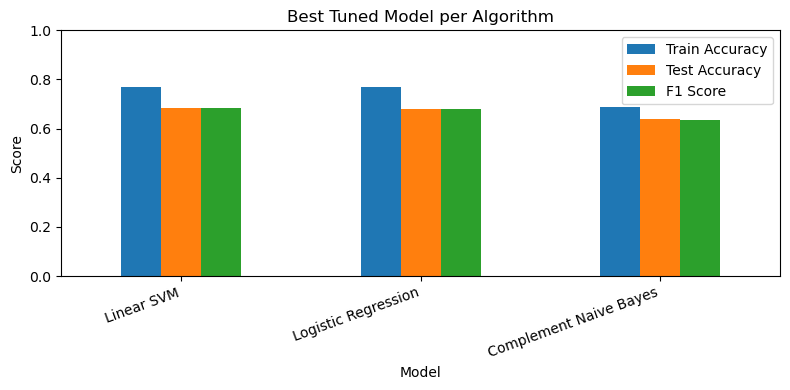

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
results_df.set_index("Model")[["Train Accuracy", "Test Accuracy", "F1 Score"]].plot(kind="bar", ax=ax)
ax.set_title("Best Tuned Model per Algorithm")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


 ------------------------------------------------------------------
 4. Save the best model for evaluation
 ------------------------------------------------------------------


In [7]:
best_model = trained_models[results_df.iloc[0]["Model"]]

joblib.dump(best_model, BEST_MODEL_PATH)

results_df.to_csv(MODEL_RESULTS_PATH, index=False)

print(f"Best model: {results_df.iloc[0]['Model']}")
print(f"Best parameters: {results_df.iloc[0]['Best Parameters']}")
print(f"Training Accuracy: {results_df.iloc[0]['Train Accuracy']:.4f}")
print(f"Testing Accuracy: {results_df.iloc[0]['Test Accuracy']:.4f}")
print(f"Precision: {results_df.iloc[0]['Precision']:.4f}")
print(f"Recall: {results_df.iloc[0]['Recall']:.4f}")
print(f"F1 Score: {results_df.iloc[0]['F1 Score']:.4f}")

print(f"\nSaved model to {BEST_MODEL_PATH}")
print(f"Saved model comparison to {MODEL_RESULTS_PATH}")

Best model: Linear SVM
Best parameters: {'C': 0.075}
Training Accuracy: 0.7691
Testing Accuracy: 0.6835
Precision: 0.6867
Recall: 0.6835
F1 Score: 0.6843

Saved model to /Users/tiyasharma/Desktop/TIYA/AI ML/Project /Comments Sentimental Analysis  copy/data/best_sentiment_model.joblib
Saved model comparison to /Users/tiyasharma/Desktop/TIYA/AI ML/Project /Comments Sentimental Analysis  copy/data/model_results.csv
